In [2]:
# setting up the environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Ready")

Ready


In [3]:
#loading the dataset
df = pd.read_excel("Cleaned_Dataset.xlsx")
df.head(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice ($),ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice ($)
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
# overviewing the datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice ($)    1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice ($)   1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
# overviewing the datasets
df.shape

(1200, 14)

In [6]:
# overviewing the datasets
df.describe()

,Date,Quantity,UnitPrice ($),ItemsInCart,TotalPrice ($)
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [7]:
# overviewing the datasets
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice ($)      0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice ($)     0
dtype: int64

In [8]:
# the mean of the numerical columns
df.mean(numeric_only=True)

Quantity             2.945833
UnitPrice ($)      356.412750
ItemsInCart          5.485000
TotalPrice ($)    1053.968300
dtype: float64

In [9]:
# the median of the numerical columns
df.median(numeric_only=True)

Quantity            3.000
UnitPrice ($)     364.210
ItemsInCart         5.000
TotalPrice ($)    823.615
dtype: float64

In [10]:
# the mode of the numerical columns
df.mode().iloc[0]

OrderID                      ORD200000
Date               2023-08-20 00:00:00
CustomerID                      C14847
Product                        Printer
Quantity                           1.0
UnitPrice ($)                   127.18
ShippingAddress            533 Main St
PaymentMethod                   Online
OrderStatus                  Cancelled
TrackingNumber             TRK10003020
ItemsInCart                        5.0
CouponCode                    FREESHIP
ReferralSource               Instagram
TotalPrice ($)                  211.14
Name: 0, dtype: object

In [11]:
# the standard deviation of the numerical columns
df.std(numeric_only=True)

Quantity            1.407557
UnitPrice ($)     197.177146
ItemsInCart         2.281983
TotalPrice ($)    819.856558
dtype: float64

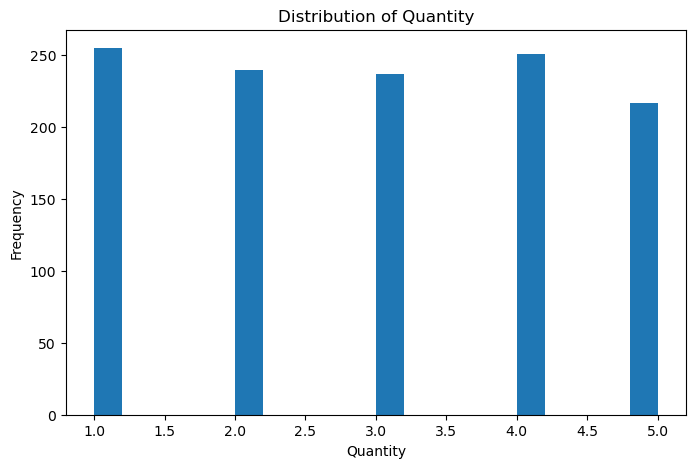

<Figure size 640x480 with 0 Axes>

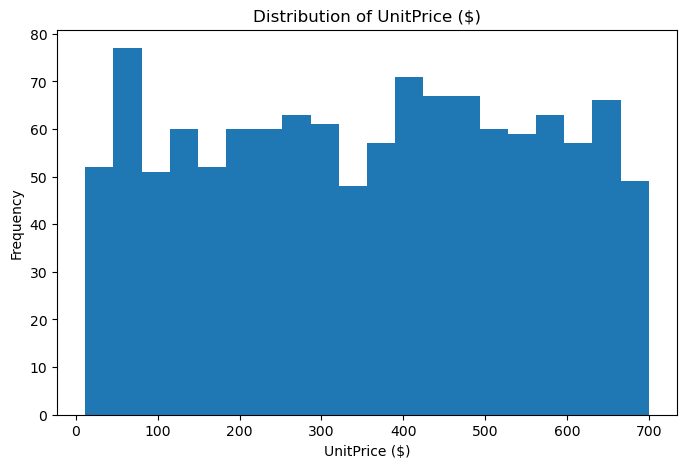

<Figure size 640x480 with 0 Axes>

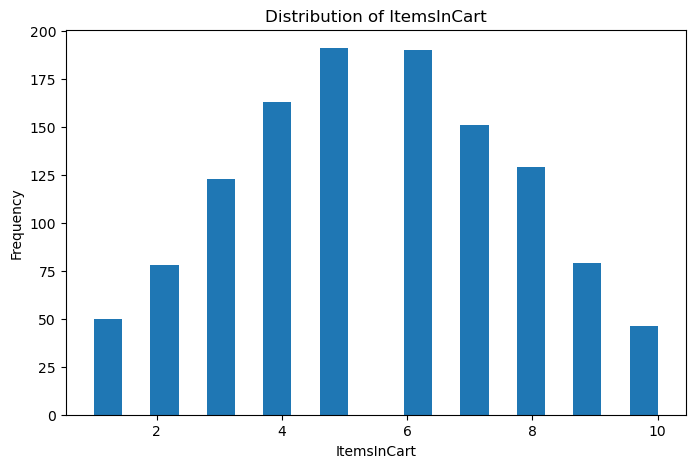

<Figure size 640x480 with 0 Axes>

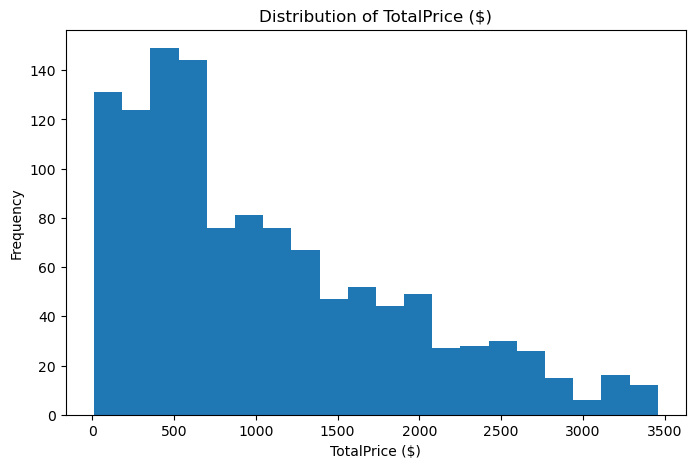

<Figure size 640x480 with 0 Axes>

In [ ]:
# distribution of numerical cols with a histrogram
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:

    plt.figure(figsize=(8,5))

    plt.hist(df[col], bins=20)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()
    

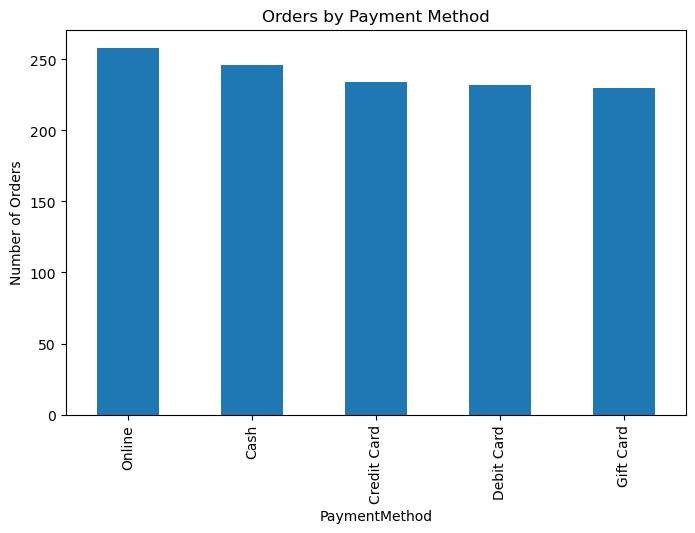

In [ ]:
# Paymentmethod analysis plot
payment = df["PaymentMethod"].value_counts()

payment.plot(kind="bar", figsize=(8,5))

plt.title("Orders by Payment Method")

plt.ylabel("Number of Orders")

plt.show()

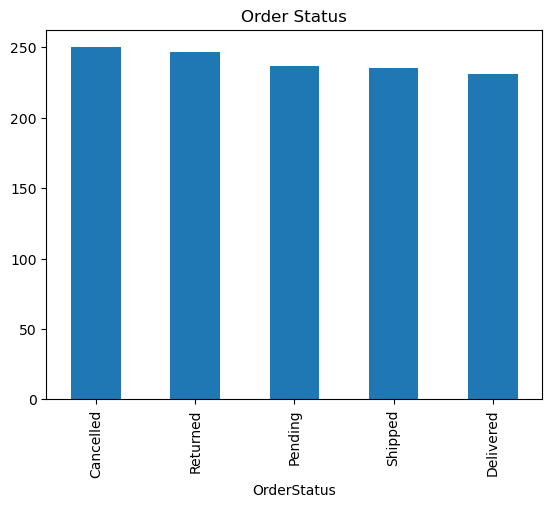

In [ ]:
# order status plot
status = df["OrderStatus"].value_counts()

status.plot(kind="bar")

plt.title("Order Status")

plt.show()

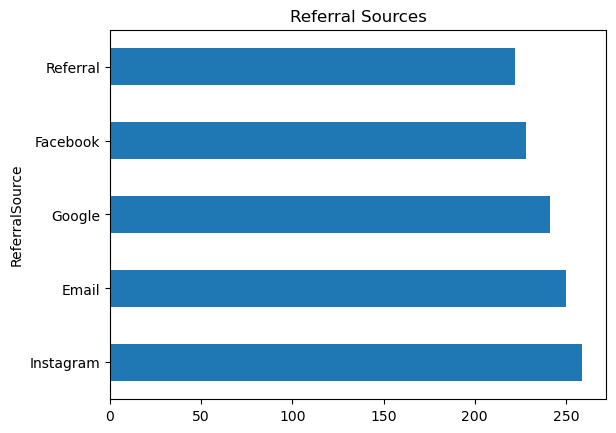

In [ ]:
# referral sources plot
referral = df["ReferralSource"].value_counts()

referral.plot(kind="barh")

plt.title("Referral Sources")

plt.show()

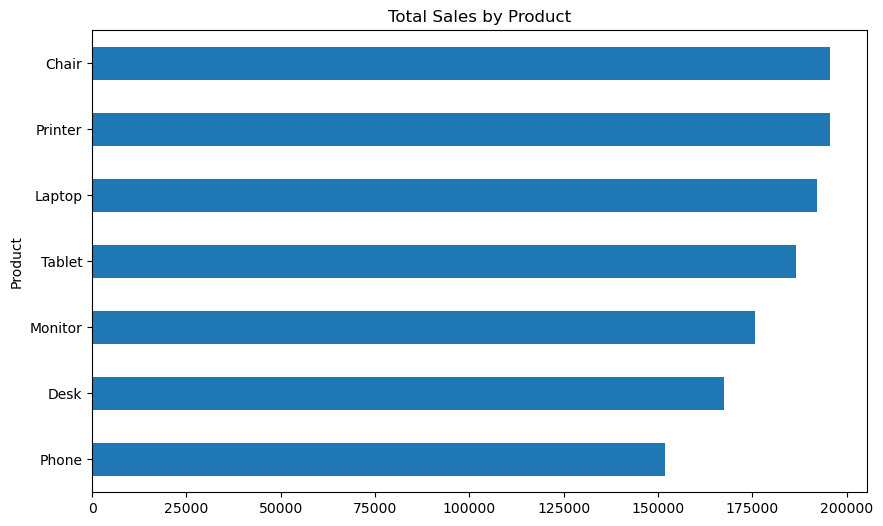

In [19]:
# Top selling products
sales = df.groupby("Product")["TotalPrice ($)"].sum().sort_values()

sales.plot(kind="barh", figsize=(10,6))

plt.title("Total Sales by Product")

plt.show()

In [ ]:
#Average order by payment
df.groupby("PaymentMethod")["TotalPrice ($)"].mean().sort_values()

PaymentMethod
Debit Card     1001.556810
Online         1017.220698
Cash           1056.041829
Gift Card      1070.973565
Credit Card    1127.553974
Name: TotalPrice ($), dtype: float64

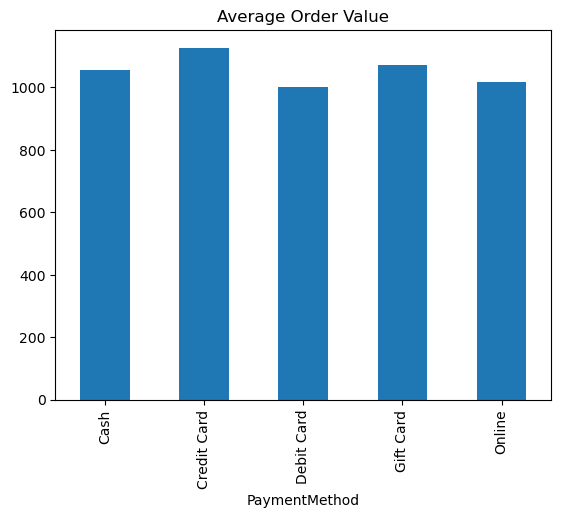

In [ ]:
#Average order by payment plot
avg = df.groupby("PaymentMethod")["TotalPrice ($)"].mean()

avg.plot(kind="bar")

plt.title("Average Order Value")

plt.show()

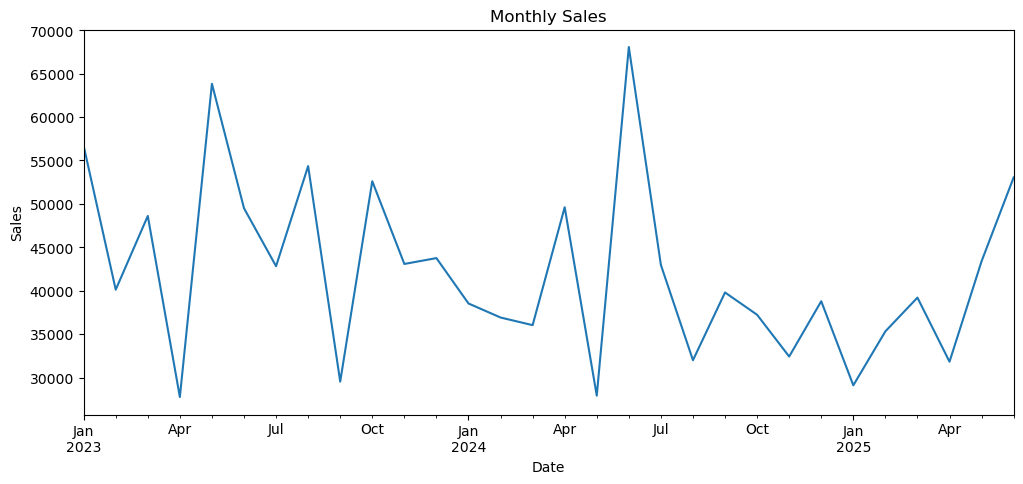

In [ ]:
# monthly sales plot
monthly = df.groupby(df["Date"].dt.to_period("M"))["TotalPrice ($)"].sum()

monthly.plot(figsize=(12,5))

plt.title("Monthly Sales")

plt.ylabel("Sales")

plt.show()

In [27]:
# correlation check
corr = df.select_dtypes(include="number").corr()

corr

,Quantity,UnitPrice ($),ItemsInCart,TotalPrice ($)
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice ($),0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice ($),0.615251,0.717081,0.392540,1.000000


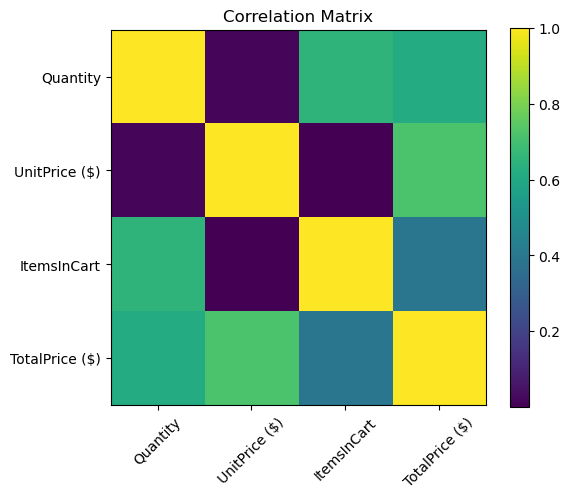

In [28]:
# correlation check plot
plt.figure(figsize=(6,5))

plt.imshow(corr, interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

# Business Insights

The exploratory data analysis revealed several important patterns within the retail sales dataset:

1. **Customer Purchasing Behavior**

   * Most customer orders consisted of relatively small quantities, indicating that individual purchases are generally modest rather than bulk orders.
   * The distribution of order values is positively skewed, with a few high-value transactions contributing significantly to total revenue.

2. **Product Performance**

   * Product sales are unevenly distributed, with a small number of products generating a substantial share of total revenue.
   * These products should be considered key revenue drivers and monitored closely for inventory planning.

3. **Payment Preferences**

   * Customers use multiple payment methods; however, some payment methods generate higher average order values than others.
   * Credit Card transactions recorded the highest average order value, suggesting customers making larger purchases tend to prefer card payments.

4. **Sales Trend**

   * Monthly sales fluctuate over time, indicating varying customer demand throughout the year.
   * These fluctuations may reflect seasonal purchasing behavior or promotional activities.

5. **Correlation Analysis**

   * Total Price shows a moderate positive relationship with both Quantity purchased and Unit Price.
   * Quantity also demonstrates a positive relationship with Items in Cart, indicating that customers purchasing more items generally place larger orders.

6. **Data Quality**

   * The dataset contains complete records after cleaning, with no missing values or duplicate entries, making it suitable for further business intelligence and predictive analytics.


# Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations are proposed:

1. **Prioritize High-Performing Products**

   * Maintain sufficient inventory for products generating the highest revenue to minimize stock shortages.

2. **Improve Marketing Strategy**

   * Develop targeted promotional campaigns for lower-performing products to increase customer awareness and sales.

3. **Leverage Customer Payment Preferences**

   * Since Credit Card transactions have the highest average order value, consider offering incentives such as loyalty rewards or discounts for card payments.

4. **Prepare for Seasonal Demand**

   * Analyze peak sales periods in greater detail and align inventory planning and marketing campaigns with expected increases in customer demand.

5. **Monitor High-Value Transactions**

   * Review unusually large transactions to distinguish legitimate premium purchases from potential data entry errors or fraudulent activities.

6. **Maintain Data Quality**

   * Continue implementing routine data validation procedures before conducting business analysis to ensure reliable and accurate decision-making.


# Conclusion

This Exploratory Data Analysis successfully examined the retail sales dataset to uncover patterns, trends, and relationships among key business variables.

The analysis confirmed that the dataset is clean, complete, and suitable for analytical purposes. Descriptive statistics, distribution analysis, trend analysis, and correlation analysis provided valuable insights into customer purchasing behavior, product performance, payment preferences, and sales trends.

The findings demonstrate that data-driven decision-making can help improve inventory management, optimize marketing strategies, and enhance overall business performance. This project also highlights the importance of exploratory data analysis as a critical step before developing predictive models or business intelligence dashboards.
